In [1]:
import matplotlib as mpl

import numpy as np
import matplotlib.pyplot as plt


import matplotlib.patheffects as pe
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *

EXT='pdf'
DPI=400

abcd = 'abcdefghijklmnopqrstuvwxyz'

time_min = 1e3
tmp_min = 1500.0
tmp_max = 4000.0

t_ini = 50e6 # years

ages_Ga = {
    "CAI":              4.57, #  https://www.nature.com/articles/nature03882
    "Earth formed":     4.54, #  https://www.lyellcollection.org/doi/abs/10.1144/GSL.SP.2001.190.01.14
    "Moon formed":      4.34, #  https://onlinelibrary.wiley.com/doi/10.1111/maps.12373
    "MO early":         4.40, #  https://www.sciencedirect.com/science/article/pii/S0012821X05002773?via%3Dihub
    "MO late" :         4.20, #  https://www.science.org/doi/10.1126/science.ads8461
    "GOE early":        2.5,  #  https://link.springer.com/chapter/10.1007/978-3-030-16057-9_5
    "GOE late" :        2.2,  #  https://link.springer.com/chapter/10.1007/978-3-030-16057-9_5
}

ages_yr = {k: (ages_Ga["CAI"] - v ) * 1e9 - t_ini for k, v in ages_Ga.items()}

In [2]:
def _planck(t, eps=1.0):
    sigma = 5.67e-8
    return eps * sigma * t**4

In [3]:
models = list_models()
models

['gooey', 'neongooey', 'lincs', 'moai', 'pacman', 'proteus', 'planatmo']

In [4]:
models_data = {}
for m in models:
    models_data[m] = load_model_data(m, quiet=True)

Loading model gooey
Loading model neongooey
Loading model lincs
Loading model moai
Loading model pacman
Loading model proteus
Loading model planatmo


In [5]:
planets = list_planets()
planets

('earth', 'venus')

In [6]:
print(", ".join(models_data["proteus"]["earth"]["Hhigh-Chigh-evo"].keys()))

t(yr), T_surf(K), T_pot(K), flux_surf(W/m2), flux_OLR(W/m2), flux_ASR(W/m2), phi(vol_frac), fO2_melt(bar), fO2_solid(bar), thick_surf_bl(m), massC_solid(kg), massC_melt(kg), massC_atm(kg), massH_solid(kg), massH_melt(kg), massH_atm(kg), massO_atm(kg), p_surf(bar), p_H2O(bar), p_CO2(bar), p_CO(bar), p_H2(bar), p_CH4(bar), p_O2(bar), mmw(kg/mol), R_trans(m), R_solid(m), viscosity(Pa.s), phi(mass_frac), p_SO2(bar), p_NH3(bar), p_N2(bar), p_H2S(bar), p_S2(bar)


## Tsurf vs Phi

/tmp/ipykernel_4726/179226699.py:55: RuntimeWarning: divide by zero encountered in divide
  mask = np.argwhere(abs(x-xx[i])/xx[i]<=0.03).flatten()
/tmp/ipykernel_4726/179226699.py:55: RuntimeWarning: invalid value encountered in divide
  mask = np.argwhere(abs(x-xx[i])/xx[i]<=0.03).flatten()


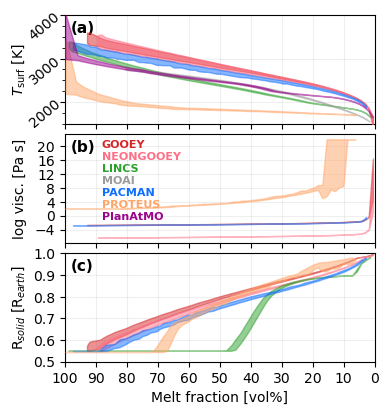

In [56]:
def compare_interior(ykeys):
    nrow = len(ykeys)
    fig,axs = plt.subplots(nrow,1, figsize=(4,1.5*nrow), sharex=True)

    for iy, ykey in enumerate(ykeys):
        ax = axs[iy]

        for im,m in enumerate(models):
            c = get_color(m)
            l = get_label(m)

            x = []
            y = []
            for p in ["earth"]:
                for case,v in models_data[m][p].items():
                    if ("-evo" not in case):
                        continue
                    x.extend(v["phi(vol_frac)"].values*100)
                    y.extend(v[ykey].values)

            # sort data
            mask = np.argsort(x)
            x = np.array(x)[mask]
            y = np.array(y)[mask]

            if len(np.unique(x)) <= 1:
                print(f"skipping {m}")
                continue
            
            if iy == 1:
                xtxt = 0.12
                ytxt = 0.9 - 0.11*im
                ax.text(xtxt, ytxt, l,  ha='left', va='center', transform=ax.transAxes,
                        # path_effects=[pe.Stroke(linewidth=3, foreground='w'), pe.Normal()],
                        zorder=30, color=c, fontsize=8, weight='bold')

            # convert units
            scatter = False
            if ykey == "R_solid(m)":
                y = y / Rearth
            elif ykey == "viscosity(Pa.s)":
                y = np.log10(y)
            elif ykey == "T_surf(K)":
                scatter = False

            if scatter:
                ax.scatter(x, y, color=c, ec='none', s=3, alpha=0.1, zorder=8, rasterized=True)

            # convert to filled region
            else:
                xx = np.linspace(min(x), max(x), 70)
                xplt = []
                ytop, ybot = [], []
                for i in range(len(xx)):
                    mask = np.argwhere(abs(x-xx[i])/xx[i]<=0.03).flatten()
                    if len(mask) > 0:
                        ytop.append(np.amax(y[mask]))
                        ybot.append(np.amin(y[mask]))
                        xplt.append(np.mean(x[mask]))

                ax.fill_between(xplt, ybot, ytop, color=c, alpha=0.5, zorder=10)


        ax.grid(alpha=0.2, zorder=0)
        ylbl = get_label(ykey)

        if ykey == "T_surf(K)":
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1000))
            ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))
            ax.set_ylim(tmp_min, tmp_max)
            ax.tick_params(axis='y', which='both', rotation=40, pad=-2)
        elif ykey == "viscosity(Pa.s)":
            ylbl = r"log visc. [Pa s]"
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(4))
        elif ykey == "R_solid(m)":
            ylbl = r"R$_{solid}$ [R$_{earth}$]"
            ax.set_ylim(0.5, 1.0)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.1))


        ax.set_ylabel(ylbl, labelpad=-0.2)
        ax.text(0.02, 0.95, f"({abcd[iy]})", transform=ax.transAxes, 
                ha='left', va='top', fontsize=11, weight='bold')

    axs[-1].set_xlabel(get_label("phi(vol_pct)"))
    axs[-1].set_xlim(right=0,left=100)
    axs[-1].xaxis.set_major_locator(mpl.ticker.MultipleLocator(10))

    # title = xlbl + " vs " + ylbl
    # axs[0].set_title(f"Interior properties", fontsize=11)

    fig.subplots_adjust(hspace=0.1)
    fig.align_labels()

    plt.show()
    fig.savefig(f"out/compare_interior.{EXT}", bbox_inches='tight', dpi=DPI, pad_inches=0.03)

compare_interior(["T_surf(K)", "viscosity(Pa.s)", "R_solid(m)"])

## Temperature over time

gooey
neongooey
lincs
moai
pacman
proteus
planatmo


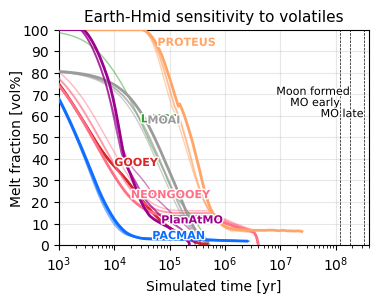

gooey
neongooey
lincs
moai
pacman
proteus
planatmo


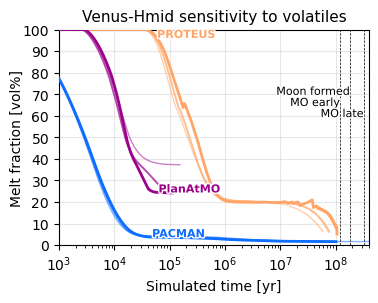

In [8]:
def plot_phi_evo(planet):
    fig,ax = plt.subplots(1,1, figsize=(4,2.8))

    xkey = "t(yr)"
    ykey = "phi(vol_frac)"

    controls = ["Hmid"]

    txts = []

    xmax = 4e8
    for im,m in enumerate(models):
        print(m)
        d = models_data[m][planet]
        col = get_color(m)
        lbl = get_label(m)

        for case in d.keys():
            if "-evo" not in case:
                continue
            if np.all([c in case for c in controls]):

                if "Chigh" in case:
                    sf = 1.0
                elif "Cmid" in case:
                    sf = 0.7
                else:
                    sf = 0.5


                x = d[case][xkey] 
                y = d[case][ykey] * 100
                ax.plot(x, y, label=lbl, color=col, lw=sf*2, alpha=sf*1, zorder=4)

                if lbl != "":
                    idx_txt = np.argmin(np.abs(x-1e4*(im+1)))
                    l = ax.text(x.iloc[idx_txt], y.iloc[idx_txt], lbl, color=col, 
                                fontsize=8, zorder=5, fontweight='bold',
                                path_effects=[pe.withStroke(linewidth=2, foreground='w')])
                    txts.append(l)

                lbl = ""


    # add vertical lines for ages of interest
    i = 0
    for k, x in ages_yr.items():
        if x > xmax:
            continue
        ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
        ax.annotate(k, xy=(x, 80), ha="right", fontsize=8, 
                    textcoords='offset points', xytext=(0,-8*i), 
                    path_effects=[pe.withStroke(linewidth=2, foreground='w')], zorder=7)
        i += 1


    ax.axvline(x=0, color="k", ls="-", lw=0.5)

    ax.set_xscale("log")
    ax.set_xlabel("Simulated time [yr]")
    ax.set_xlim(left=time_min, right=xmax)

    ax.set_ylabel(get_label("phi(vol_pct)"), labelpad=-1)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(10))


    ax.grid(alpha=0.3, zorder=-2)

    # legend of models
    # ax.legend(loc='upper left', bbox_to_anchor=(0, -0.2), ncols=4, frameon=False, handletextpad=0.5)

    title = get_label(planet) + "-" + '-'.join(controls) + " sensitivity to volatiles"
    ax.set_title(title, fontsize=11)

    plt.show()
    fig.savefig(f"out/phi_evo_{planet}.{EXT}", bbox_inches='tight', dpi=DPI)

plot_phi_evo("earth")
plot_phi_evo("venus")

In [9]:
def plot_cooling_time_bars(planet, phi):

    fig, ax = plt.subplots(1,1, figsize=(7,2.5))

    ykey = "t(yr)"

    xlbl  = []
    xlocs = []
    ymax = time_min+1
    for m in models:
        print(m)
        d = models_data[m]["earth"]
        col = get_color(m)
        lbl = get_label(m)

        # spacer
        ax.bar(m,0)
        xlocs.append(m)
        xlbl.append("")
        
        xlbl_this = None
        for case in d.keys():
            if "evo" in case:

                if "Hhigh" in case:
                    sf = 1.0
                elif "Hmid" in case:
                    sf = 0.5
                else:
                    sf = 0.3

                anno = case.split("-")[0]

                idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi))
                y = d[case][ykey].iloc[idx]

                x = m + case
                c = get_color(m)
                a = sf

                if xlbl_this is None:
                    xlbl_this = x

                hatch = ''
                if "nominal" in case:
                    hatch = '///'

                ax.bar(x, y, color=c, alpha=a, width=0.9, hatch=hatch)
                xlocs.append(x)

                ymax = max(ymax, y)

                x = case
                xlbl.append(x)

        ax.text(xlbl_this, -1e2, lbl, ha="left", va="bottom", fontsize=9, color=col, rotation_mode="anchor")
        
    i = 0
    for k, y in ages_yr.items():
        i += 1
        va = 'top'
        if k in ["Moon formed", "GOE early", "MO late"]:
            va = 'bottom'
        if y > ymax:
            continue
        ax.axhline(y, color="k", ls="--", lw=0.5, zorder=6)
        ax.annotate(k, xy=(xlocs[i*4], y), ha="left", va=va, fontsize=8)


    ax.set_ylabel(get_label(ykey) + r"($\phi=$" + f"{phi:.2f})")
    ax.set_yscale("log")
    ax.set_ylim(bottom=time_min, top=ymax*1.5)


    # show ticks on top panel and hide bottom
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    ax.set_xticks(xlocs,xlbl, fontsize=10, rotation=90, ha='right')

    fig.align_ylabels()

    title = r"Time to reach $\phi=$" + f"{phi:.2f}, " + get_label(planet)
    ax.set_title(title)

    fig.subplots_adjust(hspace=0.27)

    plt.show()
    fig.savefig(f"out/cooling_time_bars_{phi*100:.0f}.{EXT}", bbox_inches='tight', dpi=DPI)

# plot_cooling_time_bars("earth", 0.9)

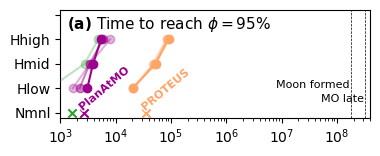

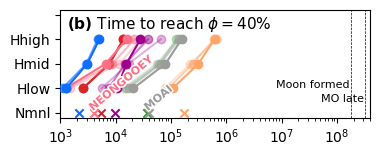

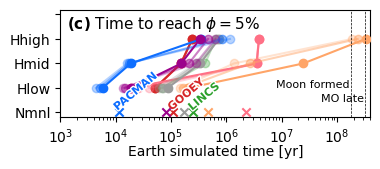

In [54]:
anno_models = { # which panel to annotate model name in
    "gooey":     2,
    "neongooey": 1,
    "lincs":     2,
    "moai":      1,
    "pacman":    2,
    "proteus":   0,
    "planatmo":  0,
}

iplt = 0
def plot_cooling_time_scat(planet, phi, xlabel=True):
    fig, ax = plt.subplots(1,1, figsize=(4,1.4))

    global iplt

    xkey = "t(yr)"
    ykey = "p_surf(bar)"

    xmax = 4e8
    for m in models:
        d = models_data[m]["earth"]
        col = get_color(m)
        lbl = get_label(m)

        # nominal case
        idx = np.argmin(np.abs(d["nominal-evo"]["phi(vol_frac)"] - phi))
        row = d["nominal-evo"].iloc[idx]

        x = row[xkey]
        y = "Nmnl"
        ax.scatter(x, y, color=col, marker='x', zorder=5)
        if anno_models[m] == iplt:
            ax.annotate(lbl, xy=(x, y), color=col, fontsize=8, 
                        ha='left', va='bottom', zorder=5, 
                        fontweight='bold',
                        rotation=40, rotation_mode='anchor',
                        path_effects=[pe.withStroke(linewidth=2, foreground='w')])

        for case_c in ["Chigh", "Cmid", "Clow"]:

            xplt = []
            yplt = []

            for case_h in ["Hlow", "Hmid", "Hhigh"]:            
                case = f"{case_h}-{case_c}-evo"
                if case not in d:
                    continue

                if "high" in case_c:
                    sf = 1.0
                elif "mid" in case_c:
                    sf = 0.5
                else:
                    sf = 0.3

                idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi))
                row = d[case].iloc[idx]
                xplt.append(row[xkey])
                yplt.append(case_h)

            if len(xplt) == 0:
                continue
            ax.plot(xplt, yplt, color=col, alpha=sf*1, zorder=4, marker='o')

    ax.scatter([1e3],[""], s=0)

        
    i = 0
    for k in ["Moon formed", "MO late", "GOE early"]:
        x = ages_yr[k]
        if x > xmax:
            continue
        ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
        ax.annotate(k, xy=(x, "Hlow"), ha="right", fontsize=8, 
                    textcoords='offset points', xytext=(-1,-10*i))
        i += 1

    # ax.legend()
    ax.set_xlim((time_min,xmax))
    ax.set_xscale("log")


    anno = r"$\bf{" + f"({abcd[iplt]})" + r"}$"
    anno += r" Time to reach $\phi=$" + f"{phi*100:.0f}%"
    ax.text(0.02, 0.95, anno, transform=ax.transAxes, 
            ha='left', va='top', fontsize=11)

    if xlabel:
        ax.set_xlabel(get_label(planet) + " simulated time [yr]", labelpad=-0.5)

    plt.show()
    fig.savefig(f"out/cooling_time_scat_{phi*100:.0f}.{EXT}", 
                bbox_inches='tight', dpi=DPI, pad_inches=0.03)

    iplt += 1

plot_cooling_time_scat("earth", 0.95, xlabel=False)
plot_cooling_time_scat("earth", 0.40, xlabel=False)
plot_cooling_time_scat("earth", 0.05, xlabel=True)

## Cooling rate as a function of temperature

gooey
nominal-evo
neongooey
nominal-evo
lincs
nominal-evo
moai
nominal-evo
pacman
nominal-evo
proteus
nominal-evo
planatmo
nominal-evo


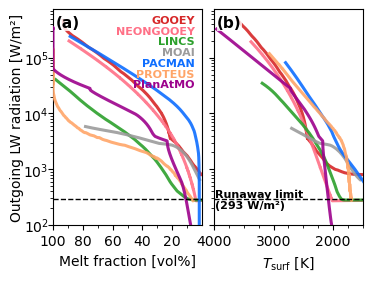

In [11]:
def plot_olr(planet):
    fig,axs = plt.subplots(1,2, figsize=(4,2.8), sharey=True)
    axl, axr = axs

    controls = ["nominal"]
    xkeys = ["phi(vol_frac)", "T_surf(K)"]

    for im,m in enumerate(models):
        print(m)
        d = models_data[m]["earth"]
        col = get_color(m)
        lbl = get_label(m)

        for case in d.keys():
            if "evo" not in case:
                continue
            if np.all([param in case for param in controls]):
                print(case)

                # idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi_compare))
                row = d[case]#.iloc[idx]

                col = get_color(m)
                al = 0.9
                lw = 2.2

                for (ax,xkey) in zip((axl, axr), xkeys):
                    mask = np.argsort(row[xkey])[::-1][10:]
                    row = row.iloc[mask]
                    
                    x = np.array(row[xkey])
                    y = np.array(row["flux_OLR(W/m2)"])#/_planck(row["T_surf(K)"]))

                    if xkey == "phi(vol_frac)":
                        x = x * 100

                    ax.plot(x, y, color=col, lw=lw, alpha=al, label=lbl, zorder=4)

        xtxt = 0.95
        ytxt = 0.95 - 0.05*im
        axl.text(xtxt, ytxt, lbl,  ha='right', va='center', transform=axl.transAxes,
                zorder=30, color=col, fontsize=8, weight='bold')

    # bb_eps = 0.01
    # xx = np.linspace(1500, 3500, 100)
    # ax.plot(xx, _planck(xx)*bb_eps, color="k", ls="--", lw=1, zorder=6)
    # ax.text(3500, _planck(3500)*bb_eps, f"Blackbody with ε = {bb_eps:.2f}", ha='right', va='bottom')

    SN_olr = 293.0
    for ax,xkey in zip((axl, axr), xkeys):

        ax.set_xlabel(get_label(xkey))
        if xkey == "phi(vol_frac)":
            ax.set_xlabel(get_label("phi(vol_pct)"))
            ax.set_xlim(right=0.1,left=100)
            ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
            ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(10))
        
        if xkey == "T_surf(K)":
            ax.set_xlim(left=tmp_max, right=tmp_min)
            ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1000))
            ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))
        
        ax.axhline(y=SN_olr, color="k", ls="--", lw=1, zorder=6)

    axr.text(tmp_max-20, SN_olr-10, 
             f"Runaway limit\n({SN_olr:.0f} W/m²)", weight='bold', color='k', fontsize=8,
             ha='left', va='center', zorder=9)
    
    axl.set_ylabel(r"Outgoing LW radiation [W/m²]", labelpad=-0.5)
    axl.tick_params(axis='y', which='both', rotation=0, pad=-0.4)
    axl.set_yscale("log")
    axl.set_ylim(bottom=1e2)

    for i in range(2):
        axs[i].text(0.02, 0.97, f"({abcd[i]})", transform=axs[i].transAxes, zorder=99,
                    bbox=dict(pad=0, fc="white", ec="none", alpha=0.8),
                    ha='left', va='top', fontsize=11, weight='bold')


    fig.subplots_adjust(wspace=0.08)

    fig.savefig(f"out/olr_{planet}.{EXT}", bbox_inches='tight', dpi=DPI)

plot_olr("earth")

## Earth versus Venus

gooey
neongooey
lincs
moai
pacman
proteus
planatmo


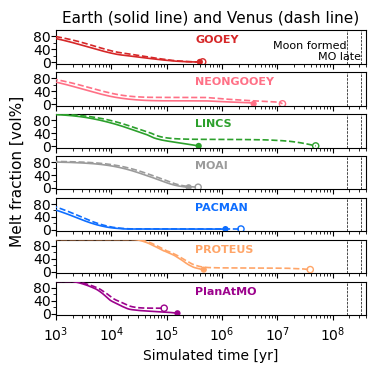

In [33]:
nrow = len(models)
fig, axs = plt.subplots(nrow,1, figsize=(4,0.2+0.5*nrow), sharex=True)

xmax = 4e8
for im,m in enumerate(models):
    ax = axs[im]
    print(m)

    if any([len(models_data[m][p]) == 0 for p in planets]):
        print("skipping model", m, "because of missing data")
        continue

    lbl = get_label(m)

    for p in planets:

        d = models_data[m][p]
        col = get_color(m)
        lw = 1.2

        if p == "earth":
            ls = "solid"
            mc = col
            ec = 'none'
        else:
            ls = "dashed"
            mc = 'none'
            ec = col

        for case in d.keys():
            if ("evo" not in case) or ("nominal" not in case):
                continue

            x = d[case]["t(yr)"] 
            y = d[case]["phi(vol_frac)"] * 100

            xmax = max(xmax,np.amax(x))

            ax.plot(x, y, color=col, ls=ls, lw=lw, zorder=4)
            ax.scatter(x.iloc[-1], y.iloc[-1], color=mc, edgecolors=ec, s=20, zorder=5)

    ax.text(0.45, 0.85, lbl,  ha='left', va='top', transform=ax.transAxes,
            zorder=30, color=col, fontsize=8, weight='bold')

    # add vertical lines for ages of interest
    for i,k in enumerate(["Moon formed", "MO late", "GOE early" ]):
        x = ages_yr[k]
        if x > xmax:
            continue
        ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
        if im == 0:
            ax.annotate(k, xy=(x, 40), 
                    ha="right", fontsize=8, textcoords='offset points', xytext=(0,-8*i))

    ax.axvline(x=0, color="k", ls="-", lw=0.5)

    ax.set_ylim(-5,99)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(40))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(20))
    ax.tick_params(axis='y', which='both', pad=-0.08)

axs[-1].set_xscale("log")
axs[-1].set_xlabel("Simulated time [yr]")
axs[-1].set_xlim(left=time_min, right=xmax)

fig.supylabel(get_label("phi(vol_pct)"), x=0.01, fontsize=11)
fig.subplots_adjust(hspace=0.25)

title = "Earth (solid line) and Venus (dash line)"
axs[0].set_title(title, fontsize=11)

plt.show()

fig.savefig(f"out/phi_evo_planets.{EXT}", bbox_inches='tight', dpi=DPI)

## Chemistry

gooey
  H2O=12.14    CO2=0.00    H2=0.00    CO=0.00    CH4=0.00    O2=0.00  
neongooey
  H2O=12.55    CO2=146.60    H2=10.00    CO=0.00    CH4=0.00    O2=0.00  
lincs
  H2O=20.86    CO2=0.00    H2=0.00    CO=0.00    CH4=0.00    O2=0.00  
moai
  H2O=6.35    CO2=9.50    H2=9.64    CO=98.14    CH4=0.00    O2=0.00  
pacman
  H2O=2.11    CO2=56.40    H2=0.24    CO=74.39    CH4=0.00    O2=0.04  
proteus
  H2O=4.26    CO2=131.14    H2=0.08    CO=13.21    CH4=0.00    O2=0.02  
planatmo
  H2O=0.00    CO2=0.00    H2=0.00    CO=0.00    CH4=0.04    O2=0.00  


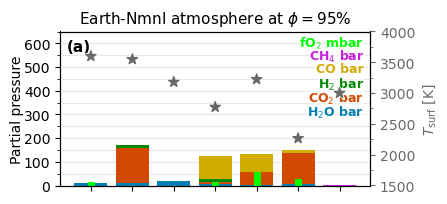

gooey
  H2O=487.91    CO2=0.00    H2=0.00    CO=0.00    CH4=0.00    O2=0.00  
neongooey
  H2O=348.93    CO2=189.27    H2=9.52    CO=0.00    CH4=0.00    O2=0.00  
lincs
  H2O=329.05    CO2=0.00    H2=0.00    CO=0.00    CH4=0.00    O2=0.00  
moai
  H2O=120.01    CO2=117.06    H2=2.41    CO=7.83    CH4=0.00    O2=0.00  
pacman
  H2O=27.49    CO2=125.27    H2=0.93    CO=22.61    CH4=0.00    O2=0.45  
proteus
  H2O=472.97    CO2=95.61    H2=5.38    CO=3.71    CH4=0.00    O2=0.00  
planatmo
  H2O=0.00    CO2=0.00    H2=0.00    CO=0.00    CH4=0.02    O2=0.00  


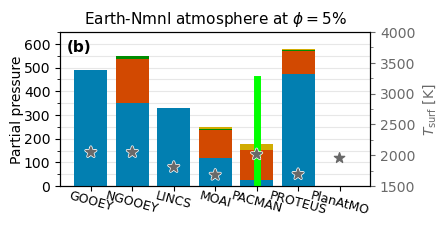

gooey
  H2O=534.04    CO2=0.00    H2=0.00    CO=0.00    CH4=0.00    O2=0.00  
neongooey
  H2O=420.27    CO2=187.77    H2=6.57    CO=0.00    CH4=0.00    O2=0.00  
lincs
  H2O=70.03    CO2=0.00    H2=0.00    CO=0.00    CH4=0.00    O2=0.00  
moai
  H2O=137.08    CO2=114.85    H2=2.57    CO=7.05    CH4=0.00    O2=0.00  
pacman
  H2O=33.83    CO2=128.38    H2=0.99    CO=19.25    CH4=0.00    O2=0.61  
proteus
  H2O=283.62    CO2=25.44    H2=3.23    CO=0.99    CH4=0.00    O2=0.00  
planatmo
  H2O=0.00    CO2=0.00    H2=0.00    CO=0.00    CH4=0.03    O2=0.00  


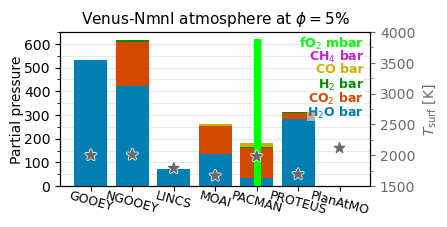

In [55]:
ymax_chem = 650
tmp_color = 'dimgray'

def plot_chem(case, planet, phi_compare, panel="", xlabel=True, legend=True):

    ykey_r = "T_surf(K)"

    fig, ax = plt.subplots(1,1, figsize=(4,2))
    axr = ax.twinx()

    fO2_factor = 1000.0

    ymax = 1
    xvals = []
    xlbls = []
    for m in models:
        print(m)
        dat = models_data[m][planet][case+"-evo"]

        idx = np.argmin(np.abs(dat["phi(vol_frac)"] - phi_compare))
        row = dat.iloc[idx]

        # total pressure
        # ax.bar(m, row["p_surf(bar)"], color=get_color("p_surf(bar)"), zorder=2, alpha=0.5)

        ybot = 0
        for gas in chili_gases:
            if gas == "O2":
                key = f"fO2_melt(bar)"
            else:
                key = f"p_{gas}(bar)"

            dy = row[key]
            if not (dy >= 0):
                dy = 0
            print(f"  {gas}={dy:.2f}  ", end='')
            
            c = get_color(gas)
            ax.bar(m, dy, bottom=ybot, color=c, zorder=3)
            ybot += dy
        print("")
        ymax = max(ymax, ybot+dy)

        # temperature on secondary axis
        axr.scatter(m, row[ykey_r], color=tmp_color, zorder=5, marker='*', s=60,
                    path_effects=[pe.withStroke(linewidth=2, foreground='w')])

        # visualise fO2
        fO2 = row[f"fO2_melt(bar)"]
        if fO2>0:
            ax.plot([m,m], [0,fO2*fO2_factor], color=get_color("O2"), lw=5, zorder=5)
       
        xvals.append(m)
        if xlabel:
            xlbl = get_label(m).replace("NEONGOOEY","NGOOEY")
        else:
            xlbl = ""
        xlbls.append(xlbl)
        
    # legend
    if legend:
        # for gas in chili_gases[::-1]:
        #     lbl = get_label(gas)
        #     if gas == "O2":
        #         lbl += r"$\times$" + f"{fO2_factor:.0f}"
        #     ax.bar(0, 0, color=get_color(gas), label=lbl)
        # ax.legend(ncols=len(chili_gases), loc='upper center', bbox_to_anchor=(0.5, 1.01), 
        #           fontsize=9, handletextpad=0.1, columnspacing=0.9, handlelength=1, frameon=False)

        
        for igas,gas in enumerate(chili_gases[::-1]):
            lbl = get_label(gas)
            if gas == "O2":
                lbl = "f" + lbl + " mbar"
            else:
                lbl += " bar"
            ax.text(0.98, 0.98-igas*0.09, lbl, color=get_color(gas), fontsize=9, transform=ax.transAxes,
                    ha='right', va='top', zorder=99, fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=0))

    ax.text(0.02, 0.95, panel, transform=ax.transAxes, 
            ha='left', va='top', fontsize=11, weight='bold')

    ax.set_ylabel("Partial pressure", labelpad=-0.1)
    ax.set_ylim(0, ymax_chem)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(50))
    ax.grid(axis='y', which='both', zorder=-2, alpha=0.3)
    ax.set_xticks(xvals, xlbls, rotation=-15, ha='center', fontsize=9)
    ax.tick_params(axis='x', which='both', pad=-1.5)

    axr.set_ylim(tmp_min, tmp_max)
    axr.tick_params(axis='y', which='both', color=tmp_color, labelcolor=tmp_color)
    axr.yaxis.set_major_locator(mpl.ticker.MultipleLocator(500))
    axr.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))
    axr.set_ylabel(get_label(ykey_r), color=tmp_color)

    caselbl = case 
    if "nominal" in case:
        caselbl = "Nmnl"
    title = f"{get_label(planet)}-{caselbl} atmosphere at " + r"$\phi=$" + f"{phi_compare*100:.0f}%"
    ax.set_title(title, fontsize=11)

    plt.show()
    fig.savefig(f"out/chem_{planet}_{case}_{phi_compare*100:.0f}.{EXT}", 
                bbox_inches='tight', dpi=DPI, pad_inches=0.03)

plot_chem("nominal", "earth", 0.95, panel="(a)", xlabel=False, legend=True)
plot_chem("nominal", "earth", 0.05, panel="(b)", xlabel=True, legend=False)
plot_chem("nominal", "venus", 0.05, panel="",    xlabel=True, legend=True)


gooey
  H: solid=1.72e+17, melt=2.31e+20, atm=3.53e+18
  C: solid=0.00e+00, melt=0.00e+00, atm=0.00e+00
neongooey
  H: solid=4.68e+17, melt=4.62e+20, atm=5.93e+19
  C: solid=5.47e-06, melt=6.49e-02, atm=2.08e-01
lincs
  H: solid=2.76e+17, melt=4.54e+20, atm=1.21e+19
  C: solid=0.00e+00, melt=0.00e+00, atm=0.00e+00
moai
  H: solid=2.99e+16, melt=4.60e+20, atm=2.52e+20
  C: solid=7.17e+15, melt=2.06e+19, atm=6.24e+18
pacman
  H: solid=0.00e+00, melt=4.69e+20, atm=7.05e+17
  C: solid=0.00e+00, melt=3.71e+19, atm=2.36e+20
proteus
  H: solid=0.00e+00, melt=4.69e+20, atm=1.05e+18
  C: solid=0.00e+00, melt=6.52e+19, atm=2.08e+20
planatmo
  H: solid=0.00e+00, melt=4.67e+20, atm=2.74e+18
  C: solid=0.00e+00, melt=6.18e+19, atm=2.11e+20


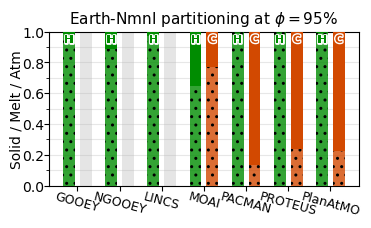

gooey
  H: solid=1.06e+19, melt=8.21e+19, atm=1.42e+20
  C: solid=0.00e+00, melt=0.00e+00, atm=0.00e+00
neongooey
  H: solid=1.99e+19, melt=2.40e+20, atm=2.52e+20
  C: solid=6.65e-05, melt=3.71e-03, atm=2.69e-01
lincs
  H: solid=1.24e+19, melt=2.62e+20, atm=1.91e+20
  C: solid=0.00e+00, melt=0.00e+00, atm=0.00e+00
moai
  H: solid=1.26e+16, melt=7.39e+19, atm=2.56e+20
  C: solid=7.29e+15, melt=2.18e+18, atm=4.19e+19
pacman
  H: solid=2.16e+20, melt=2.46e+20, atm=7.84e+18
  C: solid=1.68e+19, melt=1.14e+19, atm=2.45e+20
proteus
  H: solid=0.00e+00, melt=2.52e+20, atm=2.17e+20
  C: solid=0.00e+00, melt=2.37e+18, atm=2.69e+20
planatmo
  H: solid=1.32e+19, melt=3.15e+20, atm=1.42e+20
  C: solid=3.84e+16, melt=2.86e+18, atm=2.70e+20


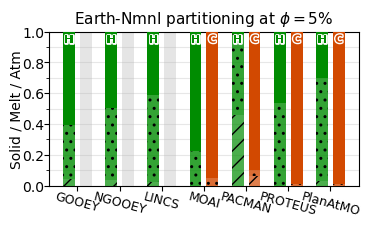

In [14]:
hatch = ["//","..",""]
alpha = [0.7, 0.8, 1.0]


def plot_partition(case, planet, phi_compare):

    bw = 0.35

    # ykey_r = "T_surf(K)"

    fig, ax = plt.subplots(1,1, figsize=(4,2))
    # axr = ax.twinx()

    xvals = []
    xlbls = []
    x = 0
    for m in models:
        print(m)
        dat = models_data[m][planet][case+"-evo"]

        idx = np.argmin(np.abs(dat["phi(vol_frac)"] - phi_compare))
        row = dat.iloc[idx]

        xlbl = get_label(m).replace("NEONGOOEY","NGOOEY")

        for elem in ["H","C"]:
            thicks = []
            c = get_color(elem)
            x += 0.5


            for key in ["solid","melt","atm"]:
                inv = row[f"mass{elem}_{key}(kg)"]
                if not np.isfinite(inv):
                    inv = 0
                thicks.append(inv)

            print(f"  {elem}: solid={thicks[0]:.2e}, melt={thicks[1]:.2e}, atm={thicks[2]:.2e}")
            
            if np.sum(thicks) < 1:
                ax.bar(x, 1, color='k', zorder=1, alpha=0.1, width=bw)
                continue 
            else:
                thicks = np.array(thicks)/np.sum(thicks) 

            for i, h in enumerate(thicks):
                ax.bar(x, h, bottom=sum(thicks[:i]), width=bw,
                       color=c, zorder=3, hatch=hatch[i], alpha=alpha[i])
                
            ax.text(x, 0.98, elem, ha='center', va='top', color=c, 
                    path_effects=[pe.withStroke(linewidth=2, foreground='w')],
                    fontsize=8, weight='bold', zorder=5)

        # temperature on secondary axis
        # axr.scatter(x-0.25, row[ykey_r], color="k", zorder=5, marker='*', s=60)

        xvals.append(x-0.25)
        xlbls.append(xlbl)
        x += 0.25
        
    ax.set_ylabel("Solid / Melt / Atm", labelpad=-1)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    ax.grid(axis='y', which='both', zorder=-2, alpha=0.3)
    ax.set_xticks(xvals, xlbls, rotation=-15, ha='center', fontsize=9)
    ax.yaxis.set_tick_params(which='both', pad=-0.5)
    ax.xaxis.set_tick_params(which='both', pad=-0.5)

    # axr.set_ylim(tmp_min, tmp_max)
    # axr.yaxis.set_major_locator(mpl.ticker.MultipleLocator(500))
    # axr.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))
    # axr.set_ylabel(get_label(ykey_r))

    caselbl = case
    if "nominal" in case:
        caselbl = "Nmnl"
    title = f"{get_label(planet)}-{caselbl} partitioning at " + r"$\phi=$" + f"{phi_compare*100:.0f}%"
    ax.set_title(title, fontsize=11)

    plt.show()
    fig.savefig(f"out/part_{planet}_{case}_{phi_compare*100:.0f}.{EXT}", bbox_inches='tight', dpi=DPI)

plot_partition("nominal", "earth", 0.95)
plot_partition("nominal", "earth", 0.05)


gooey
neongooey
lincs
moai
pacman
proteus
planatmo


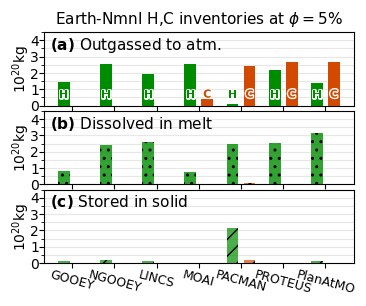

In [57]:
def plot_inventory(case, planet, phi_compare):

    bw = 0.35

    fig, axs = plt.subplots(3,1, figsize=(4,3), sharex=True)

    yscale = 1e20
    ymax = 1

    xvals = []
    xlbls = []
    x = 0
    for m in models:
        print(m)
        dat = models_data[m][planet][case+"-evo"]

        idx = np.argmin(np.abs(dat["phi(vol_frac)"] - phi_compare))
        row = dat.iloc[idx]

        xlbl = get_label(m).replace("NEONGOOEY","NGOOEY")

        for elem in ["H","C"]:
            c = get_color(elem)
            x += 0.5

            elem_tot = 0
            for i,key in enumerate(["solid","melt","atm"]):
                inv = row[f"mass{elem}_{key}(kg)"] / yscale
                axs[2-i].bar(x, inv, width=bw,
                       color=c, zorder=3, hatch=hatch[i], alpha=alpha[i])
                
                elem_tot += inv
                ymax = max(ymax, inv)
                # print(f"  {elem} {key} inventory: {inv:.2e} kg")

            if elem_tot > 1e-9:
                axs[0].text(x, 0.98, elem, ha='center', va='top', color=c, 
                        path_effects=[pe.withStroke(linewidth=2, foreground='w')],
                        fontsize=8, weight='bold', zorder=5)

        xvals.append(x-0.25)
        xlbls.append(xlbl)
        x += 0.25

    units = r"10$^{" + f"{np.log10(yscale):.0f}" + r"}$kg"
    for ax, label in zip(axs, [r"$\mathbf{(a)}$ Outgassed to atm.", r"$\mathbf{(b)}$ Dissolved in melt", r"$\mathbf{(c)}$ Stored in solid"]):
        ax.text(0.02, 0.95, label, transform=ax.transAxes, ha='left', va='top', 
                fontsize=11,)

    axs[2].set_xticks(xvals, xlbls, rotation=-15, ha='center', fontsize=9)

    for ax in axs:
        ax.set_ylim(0, 4.5)
        ax.grid(axis='y', which='both', zorder=-2, alpha=0.3)
        
        ax.yaxis.set_tick_params(which='both', pad=-0.1)
        ax.xaxis.set_tick_params(which='both', pad=-0.1)

        ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1.0))
        ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.5))
        ax.set_ylabel(units, labelpad=-1)

    # axr.set_ylim(tmp_min, tmp_max)
    # axr.yaxis.set_major_locator(mpl.ticker.MultipleLocator(500))
    # axr.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))
    # axr.set_ylabel(get_label(ykey_r))

    fig.subplots_adjust(hspace=0.07)

    caselbl = case
    if "nominal" in case:
        caselbl = "Nmnl"
    title = f"{get_label(planet)}-{caselbl} H,C inventories at " +r"$\phi=$" + f"{phi_compare*100:.0f}%"
    axs[0].set_title(title, fontsize=11)

    plt.show()
    fig.savefig(f"out/inv_{planet}_{case}_{phi_compare*100:.0f}.{EXT}", 
                bbox_inches='tight', dpi=DPI, pad_inches=0.03)

# plot_inventory("nominal", "earth", 0.95)
plot_inventory("nominal", "earth", 0.05)


## Temperature profiles

0.00010325835321 1168.139805


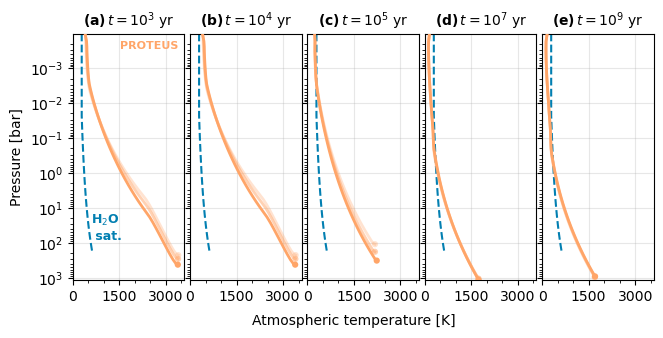

0.00010329584649 655.50744433


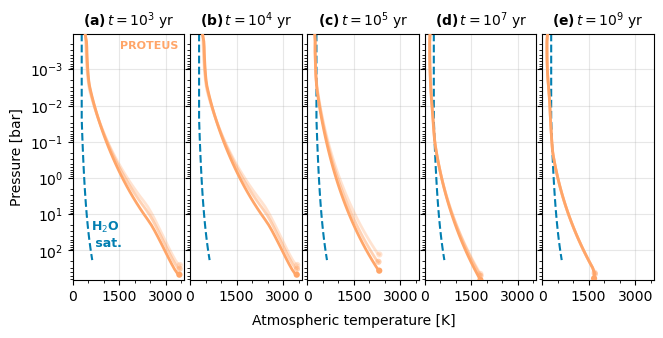

In [188]:
def tsat(p):
    # 1 celcius
    _t = np.array([20 , 25 , 30 , 34 , 40 , 44 , 50 , 54 , 60 , 70 , 80 , 90 , 96 , 100, 110, 120, 130, 140, 150, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 370], dtype=float)
    _t += 273.15

    # 1 kPa = 100 bar
    _p = np.array([2.3393 , 3.1699 , 4.2470 , 5.3251 , 7.3849 , 9.1124 , 12.352 , 15.022 , 19.946 , 31.201 , 47.414 , 70.182 , 87.771 , 101.42 , 143.38 , 198.67 , 270.28 , 361.54 , 476.16 , 618.23 , 1002.8 , 1554.9 , 2319.6 , 3346.9 , 4692.3 , 6416.6 , 8587.9 , 11284 , 14601 , 18666 , 21044 ])
    _p /= 100

    return np.interp(np.log10(p), np.log10(_p), _t,  right=np.nan)

def plot_climate(planet):

    tauvals = [3,4,5,7,9]
    ntau = len(tauvals)

    fig,axs = plt.subplots(1,ntau, figsize=(7.5,3.2), sharey=True)

    pmin, pmax = 1e-3, 1e2

    im = 0
    for m in models:
        col = get_color(m)
        lbl = get_label(m)

        any_present = False
        for itau, tau in enumerate(tauvals):
            ax = axs[itau]

            for case_c in ["Clow", "Cmid", "Chigh"]:
                case = "Hhigh-" + case_c

                if "high" in case_c:
                    sf = 1.0
                elif "mid" in case_c:
                    sf = 0.5
                else:
                    sf = 0.3

                d = models_data[m][planet]
                prof = d.get(f"{case}-tau{tau:d}", None)
                if prof is None:
                    continue
                any_present = True

                x = prof["T(K)"].values
                y = prof["p_tot(bar)"].values

                ax.plot(x, y, color=col, lw=2, label=lbl, zorder=4, alpha=sf)
                ax.scatter(x[-1], y[-1], color=col, edgecolors='none', 
                           s=20, zorder=5, alpha=sf)

                pmin = min(pmin, np.amin(y))
                pmax = max(pmax, np.amax(y))

        if any_present:
            xtxt = 0.95
            ytxt = 0.95 - 0.05*im
            axs[0].text(xtxt, ytxt, lbl,  
                        ha='right', va='center', transform=axs[0].transAxes,
                        zorder=30, color=col, fontsize=8, weight='bold')
            im += 1

    print(pmin, pmax)
    for i,ax in enumerate(axs):

        # water saturation
        parr = np.logspace(np.log10(pmin), np.log10(pmax), 100)
        tarr = tsat(parr)
        ax.plot(tarr, parr, color=get_color("H2O"), ls="--")
        if i == 0:
            itxt = np.argmin(np.abs(parr-100))
            ax.text(tarr[itxt], parr[itxt], r"H$_2$O" + "\n sat.", color=get_color("H2O"), 
                    fontsize=9,  weight='bold',
                    ha='left', va='bottom', zorder=6)

        # decorate
        ax.grid(alpha=0.3, zorder=-2)
        ax.set_yscale("log")
        ax.set_ylim(top=pmin, bottom=pmax)
        ax.set_xlim(left=0, right=3600)
        ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1500))
        ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(500))

        title =  r"${\bf(" + abcd[i] + r")}\,t=10^{" + f"{tauvals[i]:d}" + r"}$ yr"
        ax.set_title(title, fontsize=10)


    axs[0].set_ylabel("Pressure [bar]")
    fig.supxlabel("Atmospheric temperature [K]",y=-0.04, fontsize=10)
    
    fig.subplots_adjust(wspace=0.05)
    plt.show()
    fig.savefig(f"out/climate_{planet}.{EXT}", bbox_inches='tight', 
                dpi=DPI, pad_inches=0.03)

plot_climate("earth")
plot_climate("venus")